# Ethics in AI experiment 
# Lab 9 - carbon footprint of ml models
## Name - Manan Chahal
## Roll No - 23102C0044

In [3]:
import pandas as pd

train = pd.read_csv('data\\titanic.csv')

train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<Axes: >

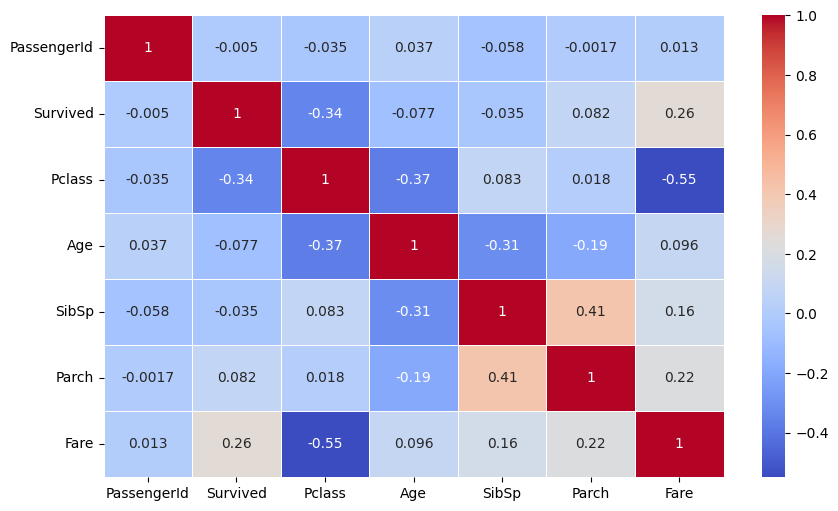

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(train.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', linewidths=0.5)

### Data Preprocessing
Handling missing values and encoding categorical features.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Drop irrelevant columns
train_df = train.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

# Handle missing values
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])

# Encode categorical columns
le = LabelEncoder()
train_df['Sex'] = le.fit_transform(train_df['Sex'])
train_df['Embarked'] = le.fit_transform(train_df['Embarked'])

X = train_df.drop(columns=['Survived'])
y = train_df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

X_train shape: (712, 7), X_test shape: (179, 7)


### Training Classifiers and Tracking CO2 Emissions
Using `codecarbon.EmissionsTracker` to measure the carbon footprint of each model's training process.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from codecarbon import EmissionsTracker
import time

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Support Vector Machine': SVC(kernel='linear')
}

results = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    tracker = EmissionsTracker(project_name=name, log_level='error')
    tracker.start()
    
    start_time = time.time()
    model.fit(X_train, y_train)
    end_time = time.time()
    
    emissions = tracker.stop()
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Emissions_kgCO2': emissions,
        'Time_s': end_time - start_time
    })
    print(f"Accuracy: {acc:.4f} | Emissions: {emissions:.8f} kgCO2")

results_df = pd.DataFrame(results)
display(results_df)

[codecarbon WARNING @ 19:48:01] Multiple instances of codecarbon are allowed to run at the same time.



Training Logistic Regression...
Accuracy: 0.8101 | Emissions: 0.00000238 kgCO2

Training Random Forest...
Accuracy: 0.8212 | Emissions: 0.00000271 kgCO2

Training Gradient Boosting...
Accuracy: 0.8101 | Emissions: 0.00000255 kgCO2

Training Support Vector Machine...
Accuracy: 0.7821 | Emissions: 0.00002988 kgCO2


,Model,Accuracy,Emissions_kgCO2,Time_s
0,Logistic Regression,0.810056,0.000002,0.038892
1,Random Forest,0.821229,0.000003,0.159021
2,Gradient Boosting,0.810056,0.000003,0.112606
3,Support Vector Machine,0.782123,0.000030,11.181880


### Visualizing Accuracy vs Emissions
Plotting the trade-off.

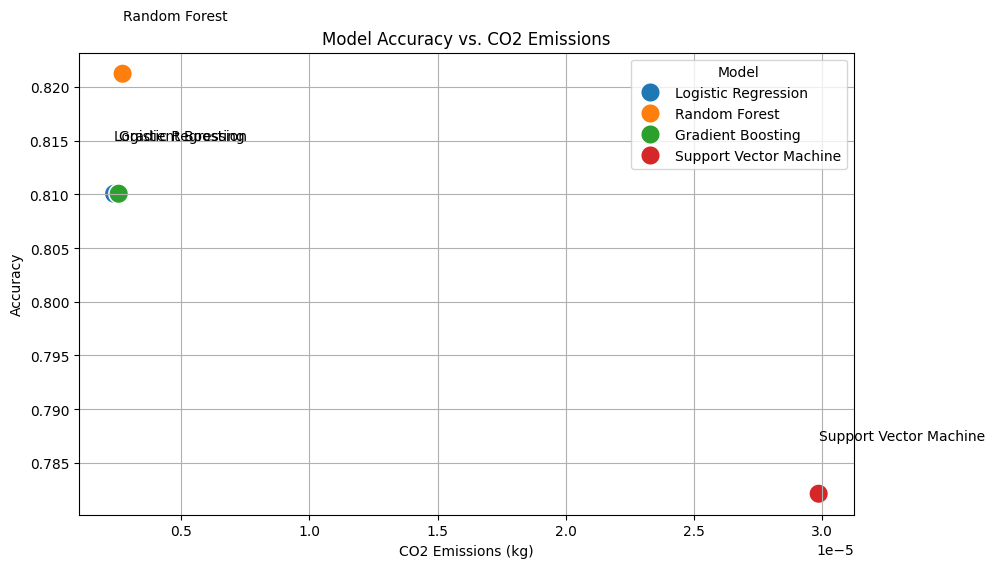

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=results_df, x='Emissions_kgCO2', y='Accuracy', hue='Model', s=200)

for i in range(results_df.shape[0]):
    plt.text(x=results_df['Emissions_kgCO2'][i], 
             y=results_df['Accuracy'][i] + 0.005, 
             s=results_df['Model'][i], 
             fontdict=dict(color='black', size=10))

plt.title('Model Accuracy vs. CO2 Emissions')
plt.xlabel('CO2 Emissions (kg)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()